# Arabic Sentiment Swap — 3 Models + Ensemble  (DialectSentEval 2026, Task 2)

**Task.** Given an Arabic sentence + its polarity, generate a *new* sentence that keeps the
meaning but **flips the sentiment**. This is a **generation** task, judged by:
Sentiment Accuracy (CAMeL classifier), BERTScore, and Perplexity (AraGPT2 fluency).

## What this notebook does
We fine-tune **three** models and then **ensemble** them by candidate re-ranking:

| # | Model | Type | Role here |
|---|-------|------|-----------|
| A | `facebook/mbart-large-50` | encoder–decoder (seq2seq) | LoRA fine-tune → generates |
| B | `CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment` | encoder-only **classifier** | wrapped as **BERT2BERT** (EncoderDecoder) → fine-tune → generates |
| C | `ALLaM-AI/ALLaM-7B-Instruct-preview` | decoder-only causal LM (7B) | **QLoRA (4-bit)** fine-tune → generates |

> **Note on model B.** `...-da-sentiment` is a *classifier* — on its own it cannot generate
> text (no decoder). To use it as a generator we attach a decoder → a **BERT2BERT** model,
> then fine-tune it. Heads-up: this same model is also the official **judge** for Sentiment
> Accuracy, so B is both a generator and (indirectly) the metric — treat B's own sentiment
> score with a grain of salt.

## Ensemble (re-ranking, not logit-averaging)
The three models use different tokenizers, so we can't average logits. Instead every model
proposes one candidate sentence, and we pick the best per input with:
`score = w_sent·(sentiment flipped?) + w_mean·BERTScore(cand, source) + w_flu·fluency(cand)`.

## Kaggle setup (do this first)
1. **Settings → Accelerator → GPU T4 x2** (needed for ALLaM 7B in 4-bit).
2. **Settings → Internet → On** (to download the models), **or** add them as Kaggle inputs.
3. Paths below are kept exactly as in your original notebook.


## 1. Setup & configuration

In [1]:
# One install cell for the whole notebook. Pinned transformers for stability with PEFT/bnb.
!pip install -q openpyxl
!pip install -q "transformers==4.46.3" datasets accelerate sentencepiece evaluate peft bitsandbytes bert-score rouge-score sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.6 MB/s eta 0:00:00


In [2]:
import urllib.request
try:
    urllib.request.urlopen("https://huggingface.co", timeout=5)
    print("الإنترنت شغّال ✅ — شغّل النوتبوك عادي")
except Exception as e:
    print("الإنترنت مقفول ❌ —", e)

الإنترنت شغّال ✅ — شغّل النوتبوك عادي


In [3]:
import warnings
warnings.filterwarnings("ignore")

import os, gc, re, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type != "cuda":
    print("⚠️  No GPU detected — turn on GPU T4 x2 in Kaggle settings (ALLaM needs it).")

Using device: cuda


In [4]:
# ================== CONFIG (flip these to control the run) ==================
WORK = "/kaggle/working"

# Which models to run
RUN_MBART      = True
RUN_BERT2BERT  = True
RUN_ALLAM      = True

# ALLaM: True = QLoRA fine-tune (chosen), False = zero-shot instruct (no training)
TRAIN_ALLAM    = True

# "Fast" profile — comfortably fits Kaggle's 12h limit. Bump these for the "Full" profile.
MBART_EPOCHS     = 6
BERT2BERT_EPOCHS = 6
ALLAM_EPOCHS     = 3          # 7B QLoRA. Heaviest model: ~1.3-1.5h/epoch on one T4 -> ~4.5h at 3 epochs

# Quick trial run: set to an int (e.g. 200) to subsample train/val/test and smoke-test the
# whole pipeline in minutes. Set to None for the real full run.
SAMPLE_N = None

# Sequence lengths (shared)
MAX_INPUT_LENGTH  = 128
MAX_TARGET_LENGTH = 128

# Ensemble re-ranking weights (sentiment dominates — that's the objective)
ENSEMBLE_WEIGHTS = {"sentiment": 1.0, "meaning": 0.35, "fluency": 0.15}

# Model checkpoints
MBART_ID    = "facebook/mbart-large-50"
CAMEL_ID    = "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"   # judge + BERT2BERT init
ALLAM_ID    = "ALLaM-AI/ALLaM-7B-Instruct-preview"

# Output dirs
MBART_DIR     = f"{WORK}/mbart_swap"
BERT2BERT_DIR = f"{WORK}/bert2bert_swap"
ALLAM_DIR     = f"{WORK}/allam_swap"
print("Config loaded ✅")

Config loaded ✅


In [5]:
# Small helper to reclaim GPU memory between the (large) models.
def free(*objs):
    for o in objs:
        try: del o
        except Exception: pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("🧹 memory freed")

## 2. Load data & quick EDA

*(Paths are unchanged from your original notebook.)*

In [6]:
TRAIN_PATH="/kaggle/input/datasets/mohammedbahgat/dialectsenteval-2026-shared-task/DialectSentEval 2026 Shared Task/Task 2/SentimentSwapPulicDevlopmentPhase/SentimentSwapSharedTaskTrain.xlsx"

VAL_PATH="/kaggle/input/datasets/mohammedbahgat/dialectsenteval-2026-shared-task/DialectSentEval 2026 Shared Task/Task 2/SentimentSwapPulicDevlopmentPhase/SentimentSwapSharedTaskVal.xlsx"

train_df=pd.read_excel(TRAIN_PATH)


val_df=pd.read_excel(VAL_PATH)

In [7]:
print(train_df.shape)
print(val_df.shape)

(6752, 4)
(964, 4)


In [8]:
train_df.head()

,id,source,source_polarity,target
0,5969,الناس المعطلة والجو جميل والحياة حلوة .. بتروح...,Negative,الناس المثمرة والجو جميل والحياة حلوة .. بتروح...
1,86,مهزلة هذو دوك أحزاب,Negative,إعجاز هذو دوك أحزاب
2,3234,اللهم ارحم امي وابوي واخوي ووالديهم وذريتهم وا...,Negative,اللهم بارك على امي وابوي واخوي ووالديهم وذريته...
3,6494,وانت بعد 💔,Negative,وانت بعد 😍
4,8298,ااه هاي زووق وبتسهل علينا الحياة كثير! 😂,Positive,ااه هاي مزعج وتسحل علينا الحياة كثير! 😞


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6752 entries, 0 to 6751
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               6752 non-null   int64 
 1   source           6752 non-null   object
 2   source_polarity  6752 non-null   object
 3   target           6752 non-null   object
dtypes: int64(1), object(3)
memory usage: 211.1+ KB


### Missing values & duplicates

In [10]:
train_df.isna().sum()

id                 0
source             0
source_polarity    0
target             0
dtype: int64

In [11]:
val_df.isna().sum()

id                 0
source             0
source_polarity    0
target             0
dtype: int64

In [12]:
print(train_df.duplicated().sum())

print(val_df.duplicated().sum())

0
0


### Sentiment distribution

In [13]:
train_df["source_polarity"].value_counts()

source_polarity
Negative    3731
Positive    3021
Name: count, dtype: int64

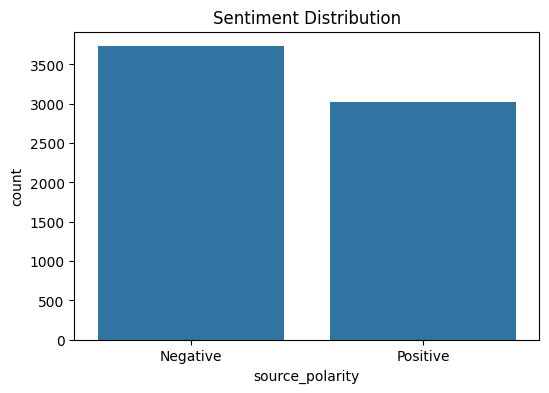

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=train_df,x="source_polarity")

plt.title("Sentiment Distribution")

plt.show()

### Sentence length (source vs target)

In [15]:
train_df["length"]=train_df["source"].apply(len)

val_df["length"]=val_df["source"].apply(len)

In [16]:
train_df["length"].describe()

count    6752.000000
mean       66.116558
std        46.439690
min         5.000000
25%        32.000000
50%        55.000000
75%        93.000000
max       500.000000
Name: length, dtype: float64

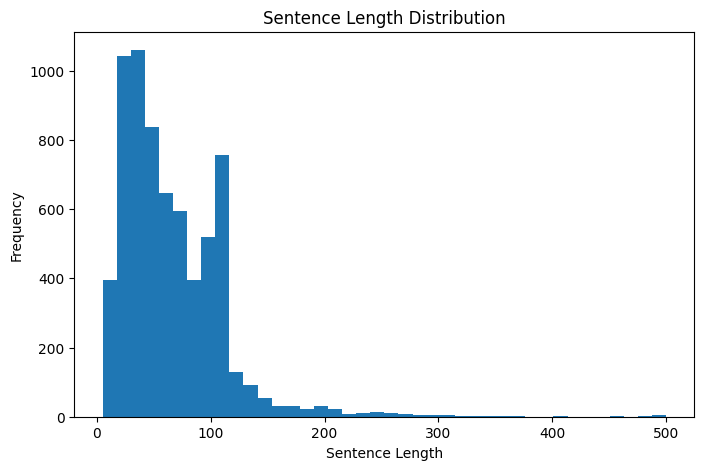

In [17]:
plt.figure(figsize=(8,5))

plt.hist(train_df["length"],bins=40)

plt.xlabel("Sentence Length")

plt.ylabel("Frequency")

plt.title("Sentence Length Distribution")

plt.show()

In [18]:
train_df["target_length"]=train_df["target"].apply(len)

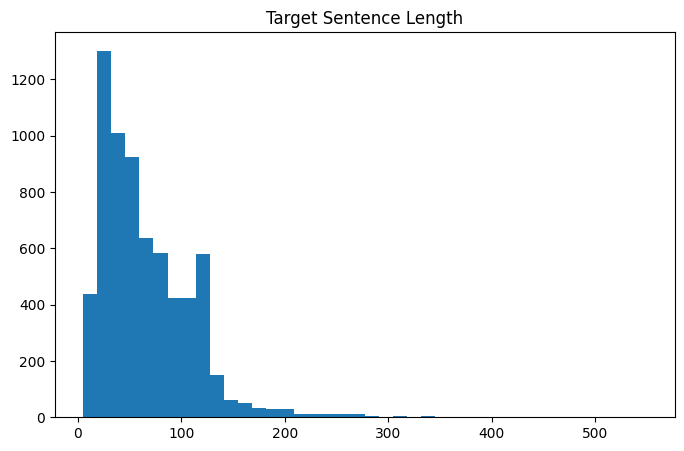

In [19]:
plt.figure(figsize=(8,5))

plt.hist(train_df["target_length"],bins=40)

plt.title("Target Sentence Length")

plt.show()

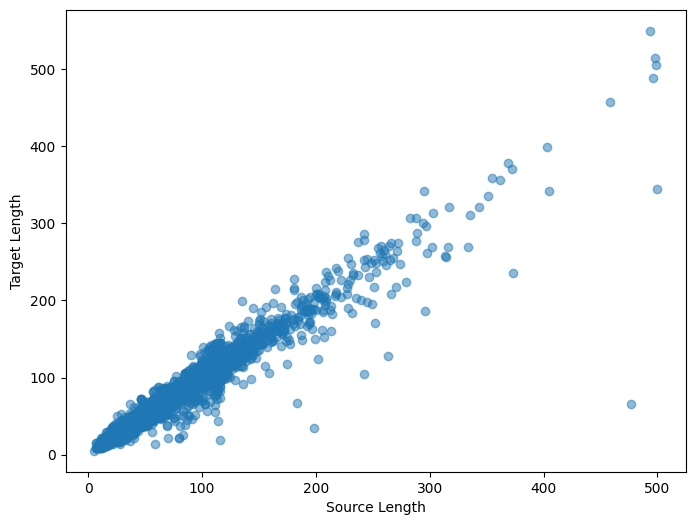

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(train_df["length"],train_df["target_length"],alpha=0.5)

plt.xlabel("Source Length")

plt.ylabel("Target Length")

plt.show()

### Random samples

In [21]:
train_df.sample(10)[["source","target","source_polarity"]]

,source,target,source_polarity
6269,صباح الخير .. اهداء لصديقه عزيزه اعتبرها اخت 💜,صباح الحزن .. إهانة لصديقه عزيزه اعتبرها اخت 💔,Positive
1410,🎶 وعن ماذآ تريد أن أحدثك !!عن قلب لاآ يحيآ بدو...,🎶 وعن ماذآ تريد أن أحدثك !!عن قلب لآ يهتم безك...,Positive
1554,من اولها هيك 😀 🐏,من اولها كذاب 😢 🚫,Positive
5169,الجو جميل ومبهج وريحة الورد ماليه المكان وحقيق...,الجو قبيح ومحزن وريحة النفايات خلاه مكان وحقيق...,Positive
2350,انتظرك ولازلت متمسك فيك وغيري للأسف فيك يقهرني 💔,أشوفك ولازلت مطمئن فيك وغيري سعادة فيك يفرحني 😊,Negative
1438,"في الليل .. ينآم الطير و البشر , ويبقى رب يراق...","في الليل .. ينآم الطير و البشر , ويبقى رب يراق...",Positive
3011,قلبي عليه من الوله جاه ماجاه وعيني على شوفه ته...,قلبي عليه من البغض جاه ماجاه وعيني على شوفه تز...,Positive
1219,ياليت عاد اني من الرياض ولا ابها 💔,الحمد الله اني في الرياض ولا ابها 😊,Negative
4747,للأبد اكره مواعيد الصبح 💔,للأبد أحب مواعيد الصبح 💖,Negative
3800,أصير فدوه لك انتي والجو. الحلو 🌹,أصير أرفض الفدوه عنك. ما أنتي ولا الجو. القبيح 💀.,Positive


## 3. Arabic normalization, prompt, and clean CSVs

In [22]:
arabic_diacritics = re.compile("""
                             ّ|
                             َ|
                             ً|
                             ُ|
                             ٌ|
                             ِ|
                             ٍ|
                             ْ|
                             ـ
                             """, re.VERBOSE)

In [23]:
def normalize_arabic(text):

    text=str(text)

    text=re.sub(arabic_diacritics,"",text)

    text=re.sub("[إأآا]","ا",text)

    text=re.sub("ى","ي",text)

    text=re.sub("ؤ","ء",text)

    text=re.sub("ئ","ء",text)

    text=re.sub("\s+"," ",text)

    return text.strip()

In [24]:
train_df["source_clean"]=train_df["source"].apply(normalize_arabic)

train_df["target_clean"]=train_df["target"].apply(normalize_arabic)

val_df["source_clean"]=val_df["source"].apply(normalize_arabic)

val_df["target_clean"]=val_df["target"].apply(normalize_arabic)

In [25]:
# def build_prompt(sentence):
#     return f"""اعكس المشاعر في الجملة التالية مع الحفاظ على نفس المعنى فقط.

# الجملة:
# {sentence}

# الناتج:
# """

def build_prompt(sentence):
    # Short fixed prefix instead of a long instruction: the model isn't instruction-tuned,
    # every example uses the exact same instruction anyway (so it carries no per-example
    # signal), and a long prefix wastes tokens out of MAX_INPUT_LENGTH + dilutes the
    # encoder's attention with LoRA's limited trainable capacity.
    return f"اعكس المشاعر: {sentence}"


In [26]:
train_df["input_text"] = train_df["source_clean"].apply(build_prompt)
val_df["input_text"] = val_df["source_clean"].apply(build_prompt)

In [27]:
train_df.to_csv(f"{WORK}/train_clean.csv", index=False)
val_df.to_csv(f"{WORK}/val_clean.csv", index=False)
print("Saved train_clean.csv / val_clean.csv")
print(train_df.columns.tolist())

Saved train_clean.csv / val_clean.csv
['id', 'source', 'source_polarity', 'target', 'length', 'target_length', 'source_clean', 'target_clean', 'input_text']


## 4. Shared evaluation utilities

One place that defines the three official-style metrics, used identically for every model
**and** the ensemble, so the comparison is fair:
- **Sentiment Accuracy** — CAMeL classifier label of the prediction == the *opposite* of the source polarity.
- **BERTScore** — vs `target` (reference) and vs `source` (meaning-preservation signal).
- **Perplexity** — AraGPT2 fluency of the generated text.

The heavy evaluator models are **lazy-loaded once** and cached.

In [28]:
import evaluate
from bert_score import score as bertscore_score
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM

train_df = pd.read_csv(f"{WORK}/train_clean.csv")
val_df   = pd.read_csv(f"{WORK}/val_clean.csv")

if SAMPLE_N is not None:
    train_df = train_df.sample(min(SAMPLE_N, len(train_df)), random_state=SEED).reset_index(drop=True)
    val_df   = val_df.sample(min(SAMPLE_N, len(val_df)),     random_state=SEED).reset_index(drop=True)
    print(f"⚡ SAMPLE_N={SAMPLE_N} -> train={len(train_df)} val={len(val_df)} (TRIAL RUN)")

def opposite(label):
    label = str(label).lower()
    if label == "positive": return "negative"
    if label == "negative": return "positive"
    return label   # neutral stays neutral

# ---- lazy singletons for the evaluator models ----
_EVAL = {}

def get_sentiment_classifier():
    if "clf" not in _EVAL:
        _EVAL["clf"] = pipeline(
            "text-classification", model=CAMEL_ID,
            device=0 if torch.cuda.is_available() else -1,
            truncation=True, max_length=128,
        )
    return _EVAL["clf"]

def get_ppl_model():
    if "ppl" not in _EVAL:
        tok = AutoTokenizer.from_pretrained("aubmindlab/aragpt2-base")
        lm  = AutoModelForCausalLM.from_pretrained("aubmindlab/aragpt2-base").to(device).eval()
        _EVAL["ppl"] = (tok, lm)
    return _EVAL["ppl"]

def classify_sentiments(texts, batch_size=64):
    clf = get_sentiment_classifier()
    out = []
    for i in range(0, len(texts), batch_size):
        chunk = [str(t) if str(t).strip() else "لا" for t in texts[i:i+batch_size]]
        out += [r["label"].lower() for r in clf(chunk)]
    return out

def fluency_perplexity(texts):
    tok, lm = get_ppl_model()
    losses = []
    for s in tqdm(texts, desc="perplexity", leave=False):
        s = str(s).strip()
        if not s: continue
        enc = tok(s, return_tensors="pt", truncation=True, max_length=128).to(device)
        if enc["input_ids"].size(1) < 2: continue
        with torch.no_grad():
            losses.append(lm(**enc, labels=enc["input_ids"]).loss.item())
    return float(np.exp(np.mean(losses))) if losses else float("nan")

def bertscore_f1(cands, refs):
    P, R, F = bertscore_score([str(c) for c in cands], [str(r) for r in refs],
                              lang="ar", verbose=False)
    return F  # tensor

In [29]:
def evaluate_predictions(preds, df, name="model"):
    # Full metric bundle for one set of predictions aligned to df rows.
    preds = [str(p) for p in preds]
    src   = df["source_clean"].astype(str).tolist()
    tgt   = df["target_clean"].astype(str).tolist()

    # Sentiment accuracy: prediction label == opposite(source polarity)
    pred_lab = classify_sentiments(preds)
    desired  = df["source_polarity"].apply(opposite).str.lower().tolist()
    sent_acc = float(np.mean([p == d for p, d in zip(pred_lab, desired)]))

    bs_tgt = float(bertscore_f1(preds, tgt).mean())
    bs_src = float(bertscore_f1(preds, src).mean())
    ppl    = fluency_perplexity(preds)
    exact  = float(np.mean([p.strip() == s.strip() for p, s in zip(preds, src)]))

    row = {"model": name, "sentiment_acc": sent_acc,
           "bertscore_vs_target": bs_tgt, "bertscore_vs_source": bs_src,
           "perplexity": ppl, "exact_copy_of_source": exact}
    print(f"[{name}]  sent_acc={sent_acc:.3f}  BERTScore(tgt)={bs_tgt:.3f}  "
          f"BERTScore(src)={bs_src:.3f}  ppl={ppl:.1f}  exact_copy={exact:.2%}")
    return row

RESULTS = []   # collects one row per model + the ensemble
print("Eval utilities ready ✅")

Eval utilities ready ✅


## 5. Model A — mBART-50 (LoRA fine-tune)

`facebook/mbart-large-50` is a pretrained multilingual encoder–decoder. We LoRA-tune it on
attention + FFN projections. mBART needs an explicit language id, so we tag everything
`ar_AR` and force the decoder to start in Arabic at generation time.

In [30]:
if RUN_MBART:
    from transformers import (MBartForConditionalGeneration, MBart50TokenizerFast,
                              DataCollatorForSeq2Seq, Seq2SeqTrainer,
                              Seq2SeqTrainingArguments, EarlyStoppingCallback)
    from peft import LoraConfig, TaskType, get_peft_model
    from datasets import Dataset

    mbart_tok = MBart50TokenizerFast.from_pretrained(MBART_ID, src_lang="ar_AR", tgt_lang="ar_AR")
    mbart = MBartForConditionalGeneration.from_pretrained(MBART_ID)
    print(f"mBART-50 params: {mbart.num_parameters():,}")

tokenizer_config.json:   0%|          | 0.00/531 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

mBART-50 params: 610,879,488


In [31]:
if RUN_MBART:
    def mbart_preprocess(batch):
        inp = mbart_tok(batch["input_text"], max_length=MAX_INPUT_LENGTH, truncation=True)
        tgt = mbart_tok(text_target=batch["target_clean"], max_length=MAX_TARGET_LENGTH, truncation=True)
        inp["labels"] = tgt["input_ids"]
        return inp

    cols = ["input_text", "target_clean"]
    mb_train = Dataset.from_pandas(train_df[cols]).map(
        mbart_preprocess, batched=True, remove_columns=cols)
    mb_val = Dataset.from_pandas(val_df[cols]).map(
        mbart_preprocess, batched=True, remove_columns=cols)
    print(mb_train, mb_val)

Map:   0%|          | 0/6752 [00:00<?, ? examples/s]

Map:   0%|          | 0/964 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 6752
}) Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 964
})


In [32]:
if RUN_MBART:
    lora_cfg = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=32, lora_alpha=64, lora_dropout=0.05, bias="none",
        target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
    )
    mbart = get_peft_model(mbart, lora_cfg)
    mbart.print_trainable_parameters()

    mbart_collator = DataCollatorForSeq2Seq(tokenizer=mbart_tok, model=mbart, padding=True)

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported

In [ ]:
if RUN_MBART:
    mbart_args = Seq2SeqTrainingArguments(
        output_dir=MBART_DIR,
        eval_strategy="epoch", save_strategy="epoch",
        learning_rate=2e-4, lr_scheduler_type="cosine", warmup_ratio=0.05,
        per_device_train_batch_size=4, per_device_eval_batch_size=4,
        gradient_accumulation_steps=8, gradient_checkpointing=False,
        num_train_epochs=MBART_EPOCHS, weight_decay=0.01,
        predict_with_generate=False,   # we pick best by eval_loss (no compute_metrics) -> generation here is wasted time
        fp16=False,
        logging_strategy="steps", logging_steps=50,
        load_best_model_at_end=True, metric_for_best_model="eval_loss",
        greater_is_better=False, report_to="none", save_total_limit=2,
    )
    mbart_trainer = Seq2SeqTrainer(
        model=mbart, args=mbart_args,
        train_dataset=mb_train, eval_dataset=mb_val,
        processing_class=mbart_tok, data_collator=mbart_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    mbart_trainer.train()
    mbart_trainer.save_model(MBART_DIR)
    mbart_tok.save_pretrained(MBART_DIR)
    print("mBART saved to", MBART_DIR)

In [ ]:
# Reusable mBART generation (used for both val predictions and, later, the test set).
def mbart_generate(texts, model, tok, batch_size=16):
    model.eval()
    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="mBART gen", leave=False):
        chunk = [str(t) for t in texts[i:i+batch_size]]
        enc = tok(chunk, return_tensors="pt", padding=True,
                  truncation=True, max_length=MAX_INPUT_LENGTH).to(model.device)
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=MAX_TARGET_LENGTH, num_beams=5,
                                  repetition_penalty=1.1, early_stopping=True,
                                  forced_bos_token_id=tok.lang_code_to_id["ar_AR"])
        preds += tok.batch_decode(out, skip_special_tokens=True)
    return preds

if RUN_MBART:
    mbart = mbart.to(device)
    val_pred_mbart = mbart_generate(val_df["input_text"].tolist(), mbart, mbart_tok)
    pd.DataFrame({"pred": val_pred_mbart}).to_csv(f"{WORK}/val_pred_mbart.csv", index=False)
    print("sample:", val_pred_mbart[:3])
    free(mbart, mbart_trainer, mbart_tok)   # release GPU before the next model

## 6. Model B — BERT2BERT from the CAMeL sentiment encoder

We turn the encoder-only `...-da-sentiment` checkpoint into a generative **EncoderDecoder**:
its BERT weights initialise both the encoder and the decoder, and fresh cross-attention
layers are added (these start random and are learned during fine-tuning). The classifier
head from the sentiment checkpoint is simply dropped. This is a small model (~2×110M) so we
full-fine-tune it (no LoRA) with fp16.

In [ ]:
if RUN_BERT2BERT:
    from transformers import (EncoderDecoderModel, AutoTokenizer as HFTok,
                              DataCollatorForSeq2Seq, Seq2SeqTrainer,
                              Seq2SeqTrainingArguments, EarlyStoppingCallback)
    from datasets import Dataset

    b2b_tok = HFTok.from_pretrained(CAMEL_ID)
    b2b = EncoderDecoderModel.from_encoder_decoder_pretrained(CAMEL_ID, CAMEL_ID)

    # Required config for a BERT2BERT generator
    b2b.config.decoder_start_token_id = b2b_tok.cls_token_id
    b2b.config.eos_token_id           = b2b_tok.sep_token_id
    b2b.config.pad_token_id           = b2b_tok.pad_token_id
    b2b.config.vocab_size             = b2b.config.decoder.vocab_size
    b2b.config.max_length             = MAX_TARGET_LENGTH
    b2b.config.no_repeat_ngram_size   = 3
    b2b.config.num_beams              = 4
    print(f"BERT2BERT params: {b2b.num_parameters():,}")

In [ ]:
if RUN_BERT2BERT:
    def b2b_preprocess(batch):
        inp = b2b_tok(batch["input_text"], max_length=MAX_INPUT_LENGTH, truncation=True, padding=False)
        tgt = b2b_tok(batch["target_clean"], max_length=MAX_TARGET_LENGTH, truncation=True, padding=False)
        inp["labels"] = tgt["input_ids"]
        return inp

    cols = ["input_text", "target_clean"]
    b2b_train = Dataset.from_pandas(train_df[cols]).map(
        b2b_preprocess, batched=True, remove_columns=cols)
    b2b_val = Dataset.from_pandas(val_df[cols]).map(
        b2b_preprocess, batched=True, remove_columns=cols)

    b2b_collator = DataCollatorForSeq2Seq(tokenizer=b2b_tok, model=b2b, padding=True)

In [ ]:
if RUN_BERT2BERT:
    b2b_args = Seq2SeqTrainingArguments(
        output_dir=BERT2BERT_DIR,
        eval_strategy="epoch", save_strategy="epoch",
        learning_rate=5e-5, lr_scheduler_type="linear", warmup_ratio=0.1,
        per_device_train_batch_size=8, per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        num_train_epochs=BERT2BERT_EPOCHS, weight_decay=0.01,
        predict_with_generate=False,   # same as mBART: best checkpoint chosen by eval_loss
        fp16=torch.cuda.is_available(),
        logging_strategy="steps", logging_steps=50,
        load_best_model_at_end=True, metric_for_best_model="eval_loss",
        greater_is_better=False, report_to="none", save_total_limit=2,
    )
    b2b_trainer = Seq2SeqTrainer(
        model=b2b, args=b2b_args,
        train_dataset=b2b_train, eval_dataset=b2b_val,
        processing_class=b2b_tok, data_collator=b2b_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    b2b_trainer.train()
    b2b_trainer.save_model(BERT2BERT_DIR)
    b2b_tok.save_pretrained(BERT2BERT_DIR)
    print("BERT2BERT saved to", BERT2BERT_DIR)

In [ ]:
def b2b_generate(texts, model, tok, batch_size=16):
    model.eval()
    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="B2B gen", leave=False):
        chunk = [str(t) for t in texts[i:i+batch_size]]
        enc = tok(chunk, return_tensors="pt", padding=True,
                  truncation=True, max_length=MAX_INPUT_LENGTH).to(model.device)
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=MAX_TARGET_LENGTH,
                                  num_beams=4, no_repeat_ngram_size=3, early_stopping=True)
        preds += tok.batch_decode(out, skip_special_tokens=True)
    return preds

if RUN_BERT2BERT:
    b2b = b2b.to(device)
    val_pred_b2b = b2b_generate(val_df["input_text"].tolist(), b2b, b2b_tok)
    pd.DataFrame({"pred": val_pred_b2b}).to_csv(f"{WORK}/val_pred_bert2bert.csv", index=False)
    print("sample:", val_pred_b2b[:3])
    free(b2b, b2b_trainer, b2b_tok)

## 7. Model C — ALLaM-7B-Instruct (QLoRA, 4-bit)

`ALLaM-7B-Instruct` is a decoder-only Arabic instruct model (SDAIA). We load it in **4-bit**
so it fits a single T4, then **QLoRA** fine-tune on the swap task. It's instruction-tuned, so
we phrase each example as a chat turn and train the model only on the *response* tokens
(the prompt is masked with `-100`).

> If `ALLAM_ID` is gated on Hugging Face, add your HF token via **Add-ons → Secrets**
> (`HF_TOKEN`) or add the model as a Kaggle input dataset.

In [ ]:
if RUN_ALLAM:
    from transformers import (AutoTokenizer, AutoModelForCausalLM,
                              BitsAndBytesConfig, Trainer, TrainingArguments,
                              DataCollatorForSeq2Seq)
    from peft import (LoraConfig, TaskType, get_peft_model,
                      prepare_model_for_kbit_training)
    from datasets import Dataset

    # Optional: pick up a Kaggle secret named HF_TOKEN if the model is gated.
    try:
        from kaggle_secrets import UserSecretsClient
        os.environ.setdefault("HF_TOKEN", UserSecretsClient().get_secret("HF_TOKEN"))
    except Exception:
        pass

    ALLAM_INSTRUCTION = ("اعكس المشاعر في الجملة التالية إلى عكسها تمامًا مع الحفاظ على نفس "
                         "المعنى والأسلوب، وأعد الجملة الجديدة فقط دون أي شرح.")

    def allam_user_msg(sentence):
        return f"{ALLAM_INSTRUCTION}\nالجملة: {sentence}"

    allam_tok = AutoTokenizer.from_pretrained(ALLAM_ID)
    if allam_tok.pad_token is None:
        allam_tok.pad_token = allam_tok.eos_token

In [ ]:
if RUN_ALLAM:
    # Build prompt ids using the chat template when available, else a plain [INST] fallback.
    def _prompt_ids(sentence):
        msgs = [{"role": "user", "content": allam_user_msg(sentence)}]
        try:
            return allam_tok.apply_chat_template(msgs, add_generation_prompt=True, tokenize=True)
        except Exception:
            text = f"[INST] {allam_user_msg(sentence)} [/INST] "
            return allam_tok(text, add_special_tokens=True)["input_ids"]

    MAX_SEQ = MAX_INPUT_LENGTH + MAX_TARGET_LENGTH

    def allam_sft_preprocess(ex):
        p_ids = _prompt_ids(ex["source_clean"])
        t_ids = allam_tok(str(ex["target_clean"]) + allam_tok.eos_token,
                          add_special_tokens=False)["input_ids"]
        input_ids = (p_ids + t_ids)[:MAX_SEQ]
        labels    = ([-100] * len(p_ids) + t_ids)[:MAX_SEQ]
        return {"input_ids": input_ids,
                "attention_mask": [1] * len(input_ids),
                "labels": labels}

    if TRAIN_ALLAM:
        cols = ["source_clean", "target_clean"]
        allam_train = Dataset.from_pandas(train_df[cols]).map(
            allam_sft_preprocess, remove_columns=cols)
        print("ALLaM SFT dataset:", allam_train)

In [ ]:
if RUN_ALLAM:
    bnb = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,   # T4 = fp16 (not bf16)
        bnb_4bit_use_double_quant=True,
    )
    allam = AutoModelForCausalLM.from_pretrained(
        ALLAM_ID, quantization_config=bnb, device_map={"": 0}, torch_dtype=torch.float16)
    allam.config.use_cache = False

In [ ]:
if RUN_ALLAM and TRAIN_ALLAM:
    allam = prepare_model_for_kbit_training(allam)
    allam_lora = LoraConfig(
        task_type=TaskType.CAUSAL_LM, r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
    )
    allam = get_peft_model(allam, allam_lora)
    allam.print_trainable_parameters()

    allam_tok.padding_side = "right"   # right padding for training
    allam_collator = DataCollatorForSeq2Seq(tokenizer=allam_tok, model=allam,
                                            padding=True, label_pad_token_id=-100)

    allam_args = TrainingArguments(
        output_dir=ALLAM_DIR,
        per_device_train_batch_size=2, gradient_accumulation_steps=8,
        learning_rate=2e-4, lr_scheduler_type="cosine", warmup_ratio=0.03,
        num_train_epochs=ALLAM_EPOCHS, weight_decay=0.0,
        fp16=True, gradient_checkpointing=True,
        logging_strategy="steps", logging_steps=25,
        save_strategy="epoch", save_total_limit=1,
        report_to="none",
    )
    allam_trainer = Trainer(model=allam, args=allam_args,
                            train_dataset=allam_train,
                            data_collator=allam_collator)
    allam_trainer.train()
    allam.save_pretrained(ALLAM_DIR)
    allam_tok.save_pretrained(ALLAM_DIR)
    print("ALLaM QLoRA adapter saved to", ALLAM_DIR)

In [ ]:
def allam_generate(sentences, model, tok, batch_size=8):
    model.eval()
    tok.padding_side = "left"   # left padding for causal generation
    preds = []
    for i in tqdm(range(0, len(sentences), batch_size), desc="ALLaM gen", leave=False):
        msgs = [[{"role": "user", "content": allam_user_msg(str(s))}]
                for s in sentences[i:i+batch_size]]
        try:
            enc = tok.apply_chat_template(msgs, add_generation_prompt=True,
                                          return_tensors="pt", padding=True,
                                          return_dict=True).to(model.device)
        except Exception:
            texts = [f"[INST] {allam_user_msg(str(s))} [/INST] " for s in sentences[i:i+batch_size]]
            enc = tok(texts, return_tensors="pt", padding=True).to(model.device)
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=MAX_TARGET_LENGTH, num_beams=2,
                                  do_sample=False, repetition_penalty=1.1,
                                  pad_token_id=tok.pad_token_id)
        gen = out[:, enc["input_ids"].shape[1]:]           # strip the prompt
        preds += [t.strip() for t in tok.batch_decode(gen, skip_special_tokens=True)]
    return preds

if RUN_ALLAM:
    val_pred_allam = allam_generate(val_df["source_clean"].tolist(), allam, allam_tok)
    pd.DataFrame({"pred": val_pred_allam}).to_csv(f"{WORK}/val_pred_allam.csv", index=False)
    print("sample:", val_pred_allam[:3])
    free(allam, allam_tok)
    if TRAIN_ALLAM:
        free(allam_trainer)

## 8. Evaluate each model on the validation set

All predictions were cached to CSV, so this section only needs the (light) evaluator models.

In [ ]:
# Load whichever prediction files exist.
pred_files = {"mBART-50": f"{WORK}/val_pred_mbart.csv",
              "BERT2BERT (CAMeL)": f"{WORK}/val_pred_bert2bert.csv",
              "ALLaM-7B (QLoRA)": f"{WORK}/val_pred_allam.csv"}

val_preds = {}
for name, path in pred_files.items():
    if os.path.exists(path):
        val_preds[name] = pd.read_csv(path)["pred"].fillna("").astype(str).tolist()
print("Loaded predictions for:", list(val_preds.keys()))

In [ ]:
RESULTS = []
for name, preds in val_preds.items():
    RESULTS.append(evaluate_predictions(preds, val_df, name=name))

## 9. Ensemble — candidate re-ranking

For every validation row we now have up to three candidate sentences. We score each candidate
and keep the best:

`score = w_sent · (does its sentiment match the target polarity?) + w_mean · BERTScore(cand, source) + w_flu · fluency`

Sentiment carries the largest weight (flipping polarity is the objective); meaning-preservation
and fluency act as tie-breakers.

In [ ]:
def desired_polarity(df):
    # Target polarity per row = opposite of source polarity (inferred if column absent).
    if "source_polarity" in df.columns:
        return df["source_polarity"].apply(opposite).str.lower().tolist()
    src_lab = classify_sentiments(df["source_clean"].astype(str).tolist())
    return [opposite(l) for l in src_lab]

def rerank_ensemble(cand_lists, df, weights=ENSEMBLE_WEIGHTS):
    # cand_lists: dict {model_name: prediction-list}, each aligned to df rows.
    n = len(df)
    model_names = list(cand_lists.keys())
    # flatten to score everything in as few passes as possible
    flat, owner = [], []
    for mi, name in enumerate(model_names):
        for ri, txt in enumerate(cand_lists[name]):
            flat.append(str(txt)); owner.append((ri, mi))

    want   = desired_polarity(df)
    labs   = classify_sentiments(flat)
    src    = df["source_clean"].astype(str).tolist()
    bs_src = bertscore_f1(flat, [src[o[0]] for o in owner]).tolist()
    ppl_t, ppl_lm = get_ppl_model()

    def one_ppl(s):
        s = str(s).strip()
        if not s: return 1e4
        enc = ppl_t(s, return_tensors="pt", truncation=True, max_length=128).to(device)
        if enc["input_ids"].size(1) < 2: return 1e4
        with torch.no_grad():
            return float(np.exp(ppl_lm(**enc, labels=enc["input_ids"]).loss.item()))
    ppls = [one_ppl(s) for s in tqdm(flat, desc="rerank ppl", leave=False)]

    # normalise fluency to [0,1] (lower ppl -> higher score) via log scale
    lp = np.log(np.clip(ppls, 1, None))
    flu = 1.0 - (lp - lp.min()) / (lp.max() - lp.min() + 1e-9)

    # build per-row candidate table
    best_pred, best_model = [""] * n, [""] * n
    per_row = {i: [] for i in range(n)}
    for k, (ri, mi) in enumerate(owner):
        sent_ok = 1.0 if labs[k] == want[ri] else 0.0
        s = (weights["sentiment"] * sent_ok
             + weights["meaning"] * bs_src[k]
             + weights["fluency"] * flu[k])
        per_row[ri].append((s, flat[k], model_names[mi]))
    for i in range(n):
        cands = sorted(per_row[i], key=lambda x: x[0], reverse=True)
        best_pred[i], best_model[i] = cands[0][1], cands[0][2]
    return best_pred, best_model

ens_pred, ens_src_model = rerank_ensemble(val_preds, val_df)
print("Chosen-model distribution:", Counter(ens_src_model))

In [ ]:
RESULTS.append(evaluate_predictions(ens_pred, val_df, name="ENSEMBLE (rerank)"))
results_df = pd.DataFrame(RESULTS).set_index("model")
results_df

In [ ]:
# Bar chart: sentiment accuracy per model + ensemble
ax = results_df["sentiment_acc"].plot(kind="bar", figsize=(8,4),
        title="Sentiment Accuracy — models vs ensemble", rot=20)
ax.set_ylabel("accuracy"); plt.tight_layout(); plt.show()
results_df.to_csv(f"{WORK}/model_comparison.csv")
print("Saved model_comparison.csv")

### Error analysis on the ensemble

In [ ]:
val_out = val_df.copy()
val_out["prediction"]  = ens_pred
val_out["chosen_model"] = ens_src_model
val_out["pred_sentiment"] = classify_sentiments(ens_pred)
val_out["desired"] = val_df["source_polarity"].apply(opposite).str.lower().values
val_out["correct_sentiment"] = val_out["pred_sentiment"] == val_out["desired"]

print("Ensemble sentiment accuracy:", val_out["correct_sentiment"].mean())
val_out.to_csv(f"{WORK}/val_predictions_ensemble.csv", index=False)
val_out[~val_out["correct_sentiment"]][
    ["source", "target", "prediction", "chosen_model"]].head(15)

## 10. Competition submission (ensemble on the test set)

Same format as before: a **`predictions.zip`** containing **`predictions.xlsx`** with columns
**`id`** and **`style`**. We regenerate candidates from each saved model one at a time
(memory-safe), then re-rank to pick the final `style` per row.

*(TEST_PATH is kept exactly as in your original notebook — update it once the organizers
release the real Task 2 test file.)*

In [ ]:
# TEST_PATH kept from the original notebook.
TEST_PATH = "/kaggle/input/datasets/mohammedbahgat/dialectsenteval-2026-shared-task/DialectSentEval 2026 Shared Task/Task 2/Test/SentimentSwapSharedTaskTest.xlsx"

test_df = pd.read_excel(TEST_PATH)
if SAMPLE_N is not None:
    test_df = test_df.head(SAMPLE_N).reset_index(drop=True)
    print(f"⚡ SAMPLE_N -> test trimmed to {len(test_df)} (TRIAL RUN — not a real submission)")
print(test_df.shape, test_df.columns.tolist())
test_df["source_clean"] = test_df["source"].apply(normalize_arabic)
test_df["input_text"]   = test_df["source_clean"].apply(build_prompt)
test_df.head()

In [ ]:
# Regenerate test candidates model-by-model, reloading each saved checkpoint on its own.
test_cands = {}

if RUN_MBART and os.path.exists(MBART_DIR):
    from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
    from peft import PeftModel
    t = MBart50TokenizerFast.from_pretrained(MBART_DIR, src_lang="ar_AR", tgt_lang="ar_AR")
    base = MBartForConditionalGeneration.from_pretrained(MBART_ID)
    m = PeftModel.from_pretrained(base, MBART_DIR).to(device)
    test_cands["mBART-50"] = mbart_generate(test_df["input_text"].tolist(), m, t)
    free(m, base, t)

if RUN_BERT2BERT and os.path.exists(BERT2BERT_DIR):
    from transformers import EncoderDecoderModel, AutoTokenizer as HFTok
    t = HFTok.from_pretrained(BERT2BERT_DIR)
    m = EncoderDecoderModel.from_pretrained(BERT2BERT_DIR).to(device)
    test_cands["BERT2BERT (CAMeL)"] = b2b_generate(test_df["input_text"].tolist(), m, t)
    free(m, t)

if RUN_ALLAM and os.path.exists(ALLAM_DIR):
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    from peft import PeftModel
    t = AutoTokenizer.from_pretrained(ALLAM_DIR)
    if t.pad_token is None: t.pad_token = t.eos_token
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                             bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
    base = AutoModelForCausalLM.from_pretrained(ALLAM_ID, quantization_config=bnb,
                                                device_map={"": 0}, torch_dtype=torch.float16)
    m = PeftModel.from_pretrained(base, ALLAM_DIR)
    test_cands["ALLaM-7B (QLoRA)"] = allam_generate(test_df["source_clean"].tolist(), m, t)
    free(m, base, t)

print("Test candidates from:", list(test_cands.keys()))

In [ ]:
# Re-rank test candidates (desired polarity inferred from source if no polarity column).
test_pred, test_choice = rerank_ensemble(test_cands, test_df)
print("Test chosen-model distribution:", Counter(test_choice))

In [ ]:
submission_df = pd.DataFrame({"id": test_df["id"], "style": test_pred})
assert submission_df["id"].is_unique, "Duplicate ids in submission"
assert submission_df["style"].isna().sum() == 0, "Some predictions are empty/NaN"

xlsx_path = os.path.join(WORK, "predictions.xlsx")
zip_path  = os.path.join(WORK, "predictions.zip")
submission_df.to_excel(xlsx_path, index=False)
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(xlsx_path, arcname="predictions.xlsx")   # file at ZIP root
print("Saved:", xlsx_path, "and", zip_path)
submission_df.head()

In [ ]:
# Archive the trained adapters/checkpoints if you want to download them.
import shutil
for d in [MBART_DIR, BERT2BERT_DIR, ALLAM_DIR]:
    if os.path.exists(d):
        shutil.make_archive(d, "zip", d)
        print("archived", d + ".zip")
print("Project finished ✅")